## 
오늘은 머리가 아파서 진행을 못했습니다.
주말에 보충하도록 하겠습니다.
죄송합니다.

### 3.5 JSON — 데이터를 주고받는 형식
- API에서 데이터를 주고받을 때 가장 널리 사용되는 형식이 JSON (JavaScript Object Notation) 입니다.- 
Python의 딕셔너리와 매우 유사하게 생겼습니

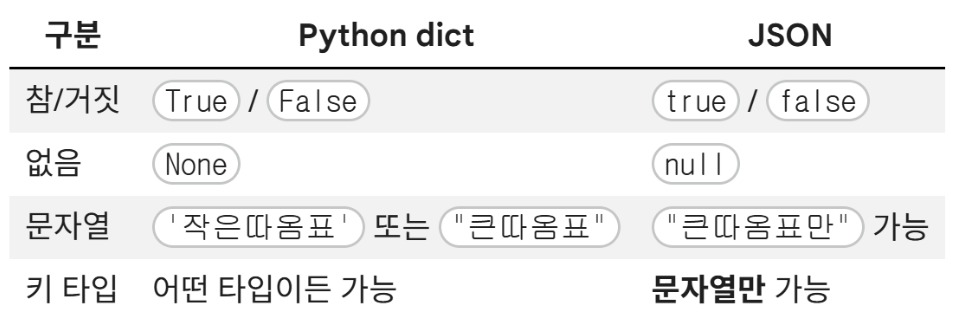다.

In [7]:
import json

# Python dict → JSON 문자열 (직렬화)
data = {
    "text": "이 영화 정말 재밌다",
    "return_probabilities": True,
    "max_length": None
}

json_string = json.dumps(data, ensure_ascii=False, indent=2)
print("=== Python → JSON ===")
print(json_string)
print(f"JSON 타입: {type(json_string)}")  #
print(f"파이썬 딕셔너리 타입: {type(data)}")

=== Python → JSON ===
{
  "text": "이 영화 정말 재밌다",
  "return_probabilities": true,
  "max_length": null
}
JSON 타입: <class 'str'>
파이썬 딕셔너리 타입: <class 'dict'>


In [9]:
# JSON 문자열 → Python dict (역직렬화)
parsed = json.loads(json_string)
print("\n=== JSON → Python ===")
print(parsed)
print(f"타입: {type(parsed)}")       #
print(f"텍스트: {parsed['text']}")   # 이 영화 정말 재밌다


=== JSON → Python ===
{'text': '이 영화 정말 재밌다', 'return_probabilities': True, 'max_length': None}
타입: <class 'dict'>
텍스트: 이 영화 정말 재밌다


### 실습: 실제 API 호출

In [12]:
import requests

# JSONPlaceholder: 테스트용 공개 REST API
response = requests.get("https://jsonplaceholder.typicode.com/posts/1")

print(f"상태 코드: {response.status_code}")   # 200
print(f"응답 타입: {type(response.json())}")   #
print(f"응답 내용:")
print(json.dumps(response.json(), indent=2))

상태 코드: 200
응답 타입: <class 'dict'>
응답 내용:
{
  "userId": 1,
  "id": 1,
  "title": "sunt aut facere repellat provident occaecati excepturi optio reprehenderit",
  "body": "quia et suscipit\nsuscipit recusandae consequuntur expedita et cum\nreprehenderit molestiae ut ut quas totam\nnostrum rerum est autem sunt rem eveniet architecto"
}


In [14]:
# POST 요청: 새로운 데이터 전송
response = requests.post(
    "https://jsonplaceholder.typicode.com/posts",
    json={                                # json= 을 사용하면 자동으로 JSON 변환 + 헤더 설정
        "title": "모델 배포 테스트",
        "body": "FastAPI로 모델을 서빙합니다",
        "userId": 1
    }
)

print(f"상태 코드: {response.status_code}")   # 201 (Created)
print(f"응답 내용:")
print(json.dumps(response.json(), ensure_ascii=False, indent=2))

상태 코드: 201
응답 내용:
{
  "title": "모델 배포 테스트",
  "body": "FastAPI로 모델을 서빙합니다",
  "userId": 1,
  "id": 101
}


In [16]:
# 존재하지 않는 리소스에 GET 요청
response = requests.get("https://jsonplaceholder.typicode.com/posts/99999")
print(f"상태 코드: {response.status_code}")   # 404 (Not Found)
print(f"응답 내용: {response.json()}")         # {}

상태 코드: 404
응답 내용: {}


In [18]:
# 잘못된 URL로 요청
try:
    response = requests.get("https://jsonplaceholder.typicode.com/없는경로")
    print(f"상태 코드: {response.status_code}")   # 404
except requests.exceptions.RequestException as e:
    print(f"요청 실패: {e}")

상태 코드: 404


### 3.7 모델 추론 API의 구조 미리보기

- 지금까지 배운 내용을 종합하면, 앞으로 만들어나갈 모델 추론 API의 구조가 보임
#### 이것이 직렬화입니다

- torch.save(model.state_dict(), "model.pth")

#### 이것이 역직렬화입니다
- model.load_state_dict(torch.load("model.pth"))

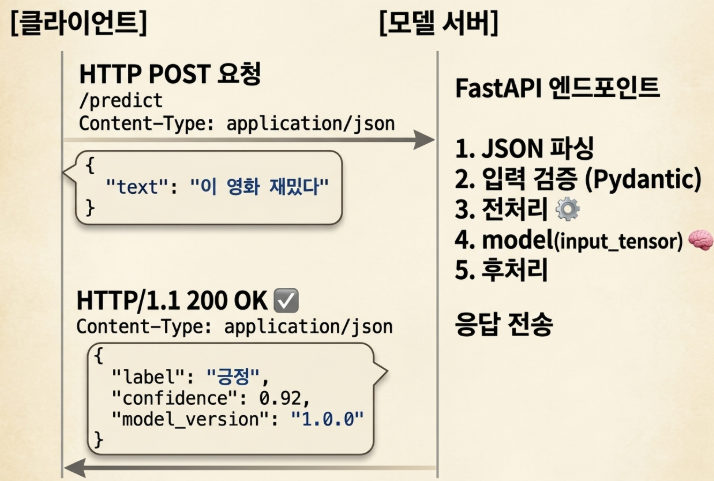

### 4.2 실습 준비: 예제 모델 만들기

In [29]:
import torch
import torch.nn as nn

class SimpleClassifier(nn.Module):
    """
    간단한 이미지 분류 모델
    - 입력: 1x28x28 (MNIST와 동일한 크기)
    - 출력: 10개 클래스에 대한 확률
    """
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [30]:
# 모델 인스턴스 생성
model = SimpleClassifier(num_classes=10)

# 더미 입력으로 동작 확인
dummy_input = torch.randn(1, 1, 28, 28)  # (batch=1, channels=1, height=28, width=28)
output = model(dummy_input)

print(f"모델 구조:\n{model}\n")
print(f"입력 크기: {dummy_input.shape}")
print(f"출력 크기: {output.shape}")          # torch.Size([1, 10])
print(f"출력 값:   {output.detach()}")

모델 구조:
SimpleClassifier(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

입력 크기: torch.Size([1, 1, 28, 28])
출력 크기: torch.Size([1, 10])
출력 값:   tensor([[ 0.0776, -0.1374,  0.1379,  0.2006,  0.0372,  0.1091,  0.1844,  0.0435,
         -0.3421,  0.0732]])


In [33]:
import os

# 모델 저장 폴더 확인
os.makedirs("models", exist_ok=True)

### 4.3 방법 1: state_dict 저장 (Pickle 기반)

가장 익숙한 방식입니다. PyTorch의 기본 저장 방식이며, 내부적으로 Python의 `pickle` 모듈을 사용합니다.

In [36]:
# state_dict: 모델의 가중치(파라미터)만 딕셔너리 형태로 저장합니다

# 1. 원본 모델을 평가 모드로 전환 (매우 중요!)
model.eval()

# 2. 원본 모델에서 출력값 생성
with torch.no_grad():
    output = model(dummy_input)

# 3. 모델 저장
torch.save(model.state_dict(), "models/model_state_dict.pth")

# 파일 크기 확인
file_size = os.path.getsize("models/model_state_dict.pth")
print(f"저장 완료: models/model_state_dict.pth")
print(f"파일 크기: {file_size / 1024:.1f} KB")

저장 완료: models/model_state_dict.pth
파일 크기: 1650.9 KB


In [38]:
# 저장된 내용 확인: 어떤 키들이 들어 있는지 살펴봅니다
state_dict = torch.load("models/model_state_dict.pth", weights_only=True)

print("저장된 키 목록:")
for key, tensor in state_dict.items():
    print(f"  {key:40s} → {tensor.shape}")


저장된 키 목록:
  features.0.weight                        → torch.Size([32, 1, 3, 3])
  features.0.bias                          → torch.Size([32])
  features.3.weight                        → torch.Size([64, 32, 3, 3])
  features.3.bias                          → torch.Size([64])
  classifier.1.weight                      → torch.Size([128, 3136])
  classifier.1.bias                        → torch.Size([128])
  classifier.4.weight                      → torch.Size([10, 128])
  classifier.4.bias                        → torch.Size([10])


#### 불러오기

In [43]:
# 불러올 때는 반드시 동일한 모델 클래스가 필요합니다
# 1. 원본 모델을 평가 모드로 전환 (매우 중요!)
model.eval()

# 2. 원본 모델에서 출력값 생성
with torch.no_grad():
    output = model(dummy_input)

# 3. 모델 저장
torch.save(model.state_dict(), "models/model_state_dict.pth")

# --- 여기서부터 불러오기 ---

# 4. 새 모델 선언 및 가중치 로드
loaded_model = SimpleClassifier(num_classes=10)
loaded_model.load_state_dict(torch.load("models/model_state_dict.pth", weights_only=True))

# 5. 불러온 모델도 평가 모드로 전환
loaded_model.eval()

# 6. 복원된 모델에서 출력값 생성
with torch.no_grad():
    loaded_output = loaded_model(dummy_input)

In [45]:
# 동일한 입력에 대해 동일한 출력이 나오는지 확인
with torch.no_grad():
    loaded_output = loaded_model(dummy_input)

print(f"원본 출력:  {output.detach()}")
print(f"복원 출력:  {loaded_output}")
print(f"동일 여부:  {torch.allclose(output.detach(), loaded_output)}")  # True

원본 출력:  tensor([[ 0.0539, -0.1715,  0.1728,  0.1487, -0.0230, -0.0537,  0.0264,  0.0463,
         -0.1783,  0.0884]])
복원 출력:  tensor([[ 0.0539, -0.1715,  0.1728,  0.1487, -0.0230, -0.0537,  0.0264,  0.0463,
         -0.1783,  0.0884]])
동일 여부:  True


#### 핵심 특징

```
장점:
  ✅ 가장 간단하고 직관적입니다.
  ✅ PyTorch 생태계에서 표준적인 방식입니다.
  ✅ 파일 크기가 작습니다 (가중치만 저장하므로).
  ✅ 학습 재개(resume)에 적합합니다.

단점:
  ❌ 모델 클래스 정의가 반드시 있어야 불러올 수 있습니다.
  ❌ Python + PyTorch 환경에서만 사용 가능합니다.
  ❌ pickle 기반이므로, 신뢰할 수 없는 파일은 보안 위험이 있습니다.
  ```

> ⚠️ **weights_only=True를 사용하는 이유**
>
> PyTorch 2.6부터 `torch.load()`의 기본 동작이 변경되었습니다.
> `pickle` 기반 로딩은 임의의 Python 코드를 실행할 수 있는 보안 위험이 있어,
> 가중치만 로드하는 `weights_only=True`가 권장됩니다.
> 이 옵션을 사용하면 state_dict에 포함된 텐서만 안전하게 불러옵니다.

### 4.4 방법 2: TorchScript

TorchScript는 PyTorch 모델을 **Python 없이도 실행할 수 있는 형태**로 변환하는 방법입니다.

```
state_dict 방식:
  .pth 파일 + 모델 클래스 정의 + Python + PyTorch  →  추론 가능

TorchScript 방식:
  .pt 파일만 있으면                  + PyTorch(또는 libtorch)  →  추론 가능
  (모델 구조가 파일 안에 포함됨)       (Python 없이도 가능)
```

#### 변환 방식: torch.jit.trace

In [54]:
# eval 모드로 전환 (Dropout, BatchNorm 등의 동작이 달라지므로 필수)
model.eval()

# trace: 더미 입력을 한 번 통과시켜서 모델의 연산 그래프를 기록합니다
traced_model = torch.jit.trace(model, dummy_input)

# 저장
traced_model.save("models/model_traced.pt")

file_size = os.path.getsize("models/model_traced.pt")
print(f"저장 완료: models/model_traced.pt")
print(f"파일 크기: {file_size / 1024:.1f} KB")


저장 완료: models/model_traced.pt
파일 크기: 1673.2 KB


#### 불러오기

In [57]:
# 핵심: 모델 클래스 정의가 필요 없습니다!
loaded_traced = torch.jit.load("models/model_traced.pt")

with torch.no_grad():
    traced_output = loaded_traced(dummy_input)

print(f"원본 출력:       {output.detach()}")
print(f"TorchScript 출력: {traced_output}")
print(f"동일 여부:        {torch.allclose(output.detach(), traced_output)}")  # True

원본 출력:       tensor([[ 0.0539, -0.1715,  0.1728,  0.1487, -0.0230, -0.0537,  0.0264,  0.0463,
         -0.1783,  0.0884]])
TorchScript 출력: tensor([[ 0.0539, -0.1715,  0.1728,  0.1487, -0.0230, -0.0537,  0.0264,  0.0463,
         -0.1783,  0.0884]])
동일 여부:        True


> `SimpleClassifier` 클래스를 `import`하지 않아도 모델이 동작합니다.  
> **모델 구조가 `.pt` 파일 안에 함께 저장**되어 있기 때문입니다.

In [62]:
# 방법 A: torch.jit.trace
# - 더미 입력을 실제로 통과시켜서 연산 경로를 기록합니다.
# - 장점: 대부분의 모델에서 잘 동작합니다.
# - 단점: 입력에 따라 분기(if/else)하는 로직은 기록되지 않습니다.
traced = torch.jit.trace(model, dummy_input)

# 방법 B: torch.jit.script
# - Python 코드를 직접 분석하여 TorchScript IR로 컴파일합니다.
# - 장점: if/else, for 루프 등 동적 로직도 변환됩니다.
# - 단점: Python 문법 중 지원되지 않는 것이 있어 에러가 발생할 수 있습니다.
scripted = torch.jit.script(model)

In [64]:
# 두 방식 모두 동일한 결과를 내는지 확인
with torch.no_grad():
    trace_out = traced(dummy_input)
    script_out = scripted(dummy_input)

print(f"trace 출력:  {trace_out}")
print(f"script 출력: {script_out}")
print(f"동일 여부:   {torch.allclose(trace_out, script_out)}")  # True

trace 출력:  tensor([[ 0.0539, -0.1715,  0.1728,  0.1487, -0.0230, -0.0537,  0.0264,  0.0463,
         -0.1783,  0.0884]])
script 출력: tensor([[ 0.0539, -0.1715,  0.1728,  0.1487, -0.0230, -0.0537,  0.0264,  0.0463,
         -0.1783,  0.0884]])
동일 여부:   True


> 💡 **실무 가이드**
>
> - 모델에 `if/else` 분기가 없다면 → `torch.jit.trace`를 사용합니다 (더 안정적).
> - 입력에 따라 다른 연산 경로를 타는 모델이라면 → `torch.jit.script`를 사용합니다.
> - 이 과정에서는 `torch.jit.trace`를 기본으로 사용합니다.

#### 핵심 특징

```
장점:
  ✅ 모델 클래스 정의 없이 불러올 수 있습니다.
  ✅ Python 없이 C++에서 실행 가능합니다 (libtorch).
  ✅ 일부 연산에서 최적화가 적용됩니다.

단점:
  ❌ 모든 Python 문법을 지원하지는 않습니다.
  ❌ 여전히 PyTorch(또는 libtorch) 런타임이 필요합니다.
  ❌ 동적 제어 흐름이 복잡한 모델은 변환이 어려울 수 있습니다.
```

### 4.5 방법 3: ONNX (Open Neural Network Exchange)

ONNX는 **프레임워크 간 호환성**을 목표로 하는 개방형 모델 포맷입니다.

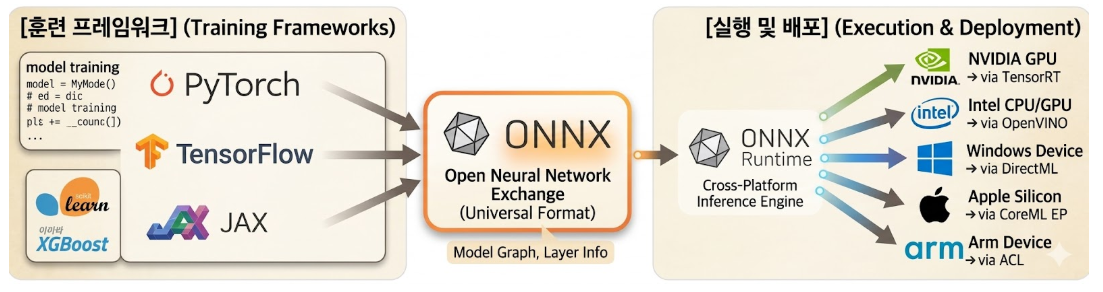

> PyTorch로 만든 모델을 TensorFlow 환경에서 실행해야 한다면?  
> 또는 NVIDIA TensorRT로 최적화된 추론을 하고 싶다면?  
> ONNX가 그 중간 다리 역할을 합니다.  다.

#### ONNX 변환 및 저장

In [74]:
# !pip install onnx onnxscript onnxruntime
import torch, onnx

model.eval()

torch.onnx.export(
    model,                                    # 변환할 모델
    dummy_input,                              # 더미 입력 (모델 트레이싱에 사용)
    "models/model.onnx",                      # 저장 경로
    export_params=True,                       # 가중치를 파일에 포함
    opset_version=17,                         # ONNX 연산자 버전
    input_names=["image"],                    # 입력 텐서 이름
    output_names=["prediction"],              # 출력 텐서 이름
    dynamic_axes={                            # 가변 크기 축 지정
        "image": {0: "batch_size"},           # batch 크기를 동적으로
        "prediction": {0: "batch_size"},
    }
)

C:\Users\hugctx\AppData\Local\Temp\ipykernel_16980\318434715.py:6: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


In [76]:
ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 17},
            producer_name='pytorch',
            producer_version='2.10.0+cpu',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"image"<FLOAT,[batch_size,1,28,28]>
            ),
            outputs=(
                %"prediction"<FLOAT,[batch_size,10]>
            ),
            initializers=(
                %"features.0.weight"<FLOAT,[32,1,3,3]>{TorchTensor(...)},
                %"features.0.bias"<FLOAT,[32]>{TorchTensor(...)},
                %"features.3.bias"<FLOAT,[64]>{TorchTensor(...)},
                %"classifier.1.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"classifier.4.bias"<FLOAT,[10]>{TorchTensor<FLOAT,[10]>(Parameter containing: tensor([ 0.0422,  0.0534, -0.0119, -0.0559, -0.0154, -0.0667, -0.0138, -0.0810, -0.0327,  0.0410], requires_grad=True), name='classifier.4.bias')},
                %"features.3.weight"<FLOAT,[64,32,3,3]>{TorchTensor(...)},
                %"classifier.1.weight"<FLOAT,[128,3136]>{TorchTensor(...)},
                %"classifier.4.weight"<FLOAT,[10,128]>{TorchTensor(...)},
                %"val_5"<INT64,[1]>{Tensor<INT64,[1]>(array([3136]), name='val_5')}
            ),
        ) {
             0 |  # node_Shape_0
                  %"val_0"<INT64,[1]> ⬅️ ::Shape(%"image") {end=1, start=0}
             1 |  # node_conv2d
                  %"conv2d"<FLOAT,[batch_size,32,28,28]> ⬅️ ::Conv(%"image", %"features.0.weight"{...}, %"features.0.bias"{...}) {group=1, pads=(1, 1, 1, 1), auto_pad='NOTSET', strides=(1, 1), dilations=(1, 1)}
             2 |  # node_relu
                  %"relu"<FLOAT,[batch_size,32,28,28]> ⬅️ ::Relu(%"conv2d")
             3 |  # node_max_pool2d
                  %"max_pool2d"<FLOAT,[batch_size,32,14,14]> ⬅️ ::MaxPool(%"relu") {storage_order=0, dilations=(1, 1), ceil_mode=0, pads=(0, 0, 0, 0), auto_pad='NOTSET', strides=(2, 2), kernel_shape=(2, 2)}
             4 |  # node_conv2d_1
                  %"conv2d_1"<FLOAT,[batch_size,64,14,14]> ⬅️ ::Conv(%"max_pool2d", %"features.3.weight"{...}, %"features.3.bias"{...}) {group=1, pads=(1, 1, 1, 1), auto_pad='NOTSET', strides=(1, 1), dilations=(1, 1)}
             5 |  # node_relu_1
                  %"relu_1"<FLOAT,[batch_size,64,14,14]> ⬅️ ::Relu(%"conv2d_1")
             6 |  # node_max_pool2d_1
                  %"max_pool2d_1"<FLOAT,[batch_size,64,7,7]> ⬅️ ::MaxPool(%"relu_1") {storage_order=0, dilations=(1, 1), ceil_mode=0, pads=(0, 0, 0, 0), auto_pad='NOTSET', strides=(2, 2), kernel_shape=(2, 2)}
             7 |  # node_Concat_4
                  %"val_6"<INT64,[2]> ⬅️ ::Concat(%"val_0", %"val_5"{[3136]}) {axis=0}
             8 |  # node_view
                  %"view"<FLOAT,[batch_size,3136]> ⬅️ ::Reshape(%"max_pool2d_1", %"val_6") {allowzero=1}
             9 |  # node_linear
                  %"linear"<FLOAT,[batch_size,128]> ⬅️ ::Gemm(%"view", %"classifier.1.weight"{...}, %"classifier.1.bias"{...}) {beta=1.0, transB=1, alpha=1.0, transA=0}
            10 |  # node_relu_2
                  %"relu_2"<FLOAT,[batch_size,128]> ⬅️ ::Relu(%"linear")
            11 |  # node_linear_1
                  %"prediction"<FLOAT,[batch_size,10]> ⬅️ ::Gemm(%"relu_2", %"classifier.4.weight"{...}, %"classifier.4.bias"{[0.042150966823101044, 0.05336741358041763, -0.011854959651827812, -0.05589584633708, -0.015437041409313679, -0.06670045107603073, -0.013799109496176243, -0.08101159334182739, -0.03269462659955025, 0.040979284793138504]}) {beta=1.0, transB=1, alpha=1.0, transA=0}
            return %"prediction"<FLOAT,[batch_size,10]>
        }


    ,
    exported_program=
        ExportedProgram:
            class GraphModule(torch.nn.Module):
                def forward(self, p_features_0_weight: "f32[32, 1, 3, 3]", p_features_0_bias: "f32[32]", p_features_3_weight: "f32[64, 32, 3, 3]", p_features_3_bias: "f32[64]", p_classifier_1_weight: "f32[128, 3136]", p_classifier_1_bias: "f32[128]", p_classifier_4_weight: "f32[10, 128]", p_classifier_4_bias: "f32[10]", x: "f32[s77, 1, 28, 28]"):
                    # No stacktrace found for following nodes
                    sym_size_int_1: "Sym(s77)" = torch.ops.aten.sym_size.int(x, 0)
            
                    # File: /usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:553 in forward, code: return self._conv_forward(input, self.weight, self.bias)
                    conv2d: "f32[s77, 32, 28, 28]" = torch.ops.aten.conv2d.default(x, p_features_0_weight, p_features_0_bias, [1, 1], [1, 1]);  x = p_features_0_weight = p_features_0_bias = None
            
                    # File: /usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:143 in forward, code: return F.relu(input, inplace=self.inplace)
                    relu: "f32[s77, 32, 28, 28]" = torch.ops.aten.relu.default(conv2d);  conv2d = None
            
                    # File: /usr/local/lib/python3.12/dist-packages/torch/nn/modules/pooling.py:224 in forward, code: return F.max_pool2d(
                    max_pool2d: "f32[s77, 32, 14, 14]" = torch.ops.aten.max_pool2d.default(relu, [2, 2], [2, 2]);  relu = None
            
                    # File: /usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:553 in forward, code: return self._conv_forward(input, self.weight, self.bias)
                    conv2d_1: "f32[s77, 64, 14, 14]" = torch.ops.aten.conv2d.default(max_pool2d, p_features_3_weight, p_features_3_bias, [1, 1], [1, 1]);  max_pool2d = p_features_3_weight = p_features_3_bias = None
            
                    # File: /usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:143 in forward, code: return F.relu(input, inplace=self.inplace)
                    relu_1: "f32[s77, 64, 14, 14]" = torch.ops.aten.relu.default(conv2d_1);  conv2d_1 = None
            
                    # File: /usr/local/lib/python3.12/dist-packages/torch/nn/modules/pooling.py:224 in forward, code: return F.max_pool2d(
                    max_pool2d_1: "f32[s77, 64, 7, 7]" = torch.ops.aten.max_pool2d.default(relu_1, [2, 2], [2, 2]);  relu_1 = None
            
                    # File: /usr/local/lib/python3.12/dist-packages/torch/nn/modules/flatten.py:55 in forward, code: return input.flatten(self.start_dim, self.end_dim)
                    view: "f32[s77, 3136]" = torch.ops.aten.view.default(max_pool2d_1, [sym_size_int_1, 3136]);  max_pool2d_1 = sym_size_int_1 = None
            
                    # File: /usr/local/lib/python3.12/dist-packages/torch/nn/modules/linear.py:134 in forward, code: return F.linear(input, self.weight, self.bias)
                    linear: "f32[s77, 128]" = torch.ops.aten.linear.default(view, p_classifier_1_weight, p_classifier_1_bias);  view = p_classifier_1_weight = p_classifier_1_bias = None
            
                    # File: /usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:143 in forward, code: return F.relu(input, inplace=self.inplace)
                    relu_2: "f32[s77, 128]" = torch.ops.aten.relu.default(linear);  linear = None
            
                    # File: /usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:73 in forward, code: return F.dropout(input, self.p, self.training, self.inplace)
                    clone: "f32[s77, 128]" = torch.ops.aten.clone.default(relu_2);  relu_2 = None
            
                    # File: /usr/local/lib/python3.12/dist-packages/torch/nn/modules/linear.py:134 in forward, code: return F.linear(input, self.weight, self.bias)
                    linear_1: "f32[s77, 10]" = torch.ops.aten.linear.default(clone, p_classifier_4_weight, p_classifier_4_bias);  clone = p_classifier_4_weight = p_classifier_4_bias = None
                    return (linear_1,)
            
        Graph signature: 
            # inputs
            p_features_0_weight: PARAMETER target='features.0.weight'
            p_features_0_bias: PARAMETER target='features.0.bias'
            p_features_3_weight: PARAMETER target='features.3.weight'
            p_features_3_bias: PARAMETER target='features.3.bias'
            p_classifier_1_weight: PARAMETER target='classifier.1.weight'
            p_classifier_1_bias: PARAMETER target='classifier.1.bias'
            p_classifier_4_weight: PARAMETER target='classifier.4.weight'
            p_classifier_4_bias: PARAMETER target='classifier.4.bias'
            x: USER_INPUT
    
            # outputs
            linear_1: USER_OUTPUT
    
        Range constraints: {s77: VR[0, int_oo]}

)


SyntaxError: invalid character '⬅' (U+2B05) (3437606344.py, line 32)

In [78]:
file_size = os.path.getsize("models/model.onnx")
print(f"저장 완료: models/model.onnx")
print(f"파일 크기: {file_size / 1024:.1f} KB")

저장 완료: models/model.onnx
파일 크기: 1649.1 KB


> 💡 **dynamic_axes가 중요한 이유**
>
> 이 설정이 없으면 모델이 `batch_size=1`로 고정됩니다.
> 배포 시에는 요청에 따라 배치 크기가 달라질 수 있으므로,
> `dynamic_axes`로 가변 축을 지정하는 것이 좋습니다.

#### ONNX 모델 검증

In [82]:
import onnx

# 모델 구조 검증
onnx_model = onnx.load("models/model.onnx")
onnx.checker.check_model(onnx_model)
print("✅ ONNX 모델 검증 통과")

# 모델 정보 확인
print(f"\n입력:")
for inp in onnx_model.graph.input:
    print(f"  이름: {inp.name}")
    shape = [d.dim_param or d.dim_value for d in inp.type.tensor_type.shape.dim]
    print(f"  크기: {shape}")

print(f"\n출력:")
for out in onnx_model.graph.output:
    print(f"  이름: {out.name}")
    shape = [d.dim_param or d.dim_value for d in out.type.tensor_type.shape.dim]
    print(f"  크기: {shape}")

✅ ONNX 모델 검증 통과

입력:
  이름: image
  크기: ['batch_size', 1, 28, 28]

출력:
  이름: prediction
  크기: ['batch_size', 10]


#### ONNX Runtime으로 추론

In [85]:
import onnxruntime as ort
import numpy as np

# ONNX Runtime 세션 생성
session = ort.InferenceSession("models/model.onnx")

# 입력 데이터 준비 (NumPy 배열로 변환)
input_data = dummy_input.numpy()

# 추론 실행
onnx_output = session.run(
    output_names=["prediction"],
    input_feed={"image": input_data}
)

In [87]:
print(f"PyTorch 출력:       {output.detach().numpy()}")
print(f"ONNX Runtime 출력:  {onnx_output[0]}")
print(f"동일 여부 (오차 허용): {np.allclose(output.detach().numpy(), onnx_output[0], atol=1e-5)}")

PyTorch 출력:       [[ 0.05394462 -0.1714672   0.17279232  0.14872327 -0.02304506 -0.05373663
   0.02635566  0.04625598 -0.17827713  0.0884472 ]]
ONNX Runtime 출력:  [[ 0.0539446  -0.17146719  0.17279232  0.14872323 -0.02304512 -0.05373662
   0.02635569  0.046256   -0.17827705  0.08844718]]
동일 여부 (오차 허용): True


> ⚠️ **소수점 미세 차이**
>
> ONNX Runtime과 PyTorch의 결과가 완벽히 동일하지 않을 수 있습니다.  
> 부동소수점 연산 순서 차이로 인한 것이며, `atol=1e-5` 수준의 오차는 정상입니다.  

#### 핵심 특징

```
장점:
  ✅ 프레임워크에 독립적입니다 (PyTorch, TensorFlow, JAX 등 어디서든 변환 가능).
  ✅ ONNX Runtime은 매우 빠른 추론 속도를 제공합니다.
  ✅ TensorRT, OpenVINO 등 하드웨어 최적화 엔진과 호환됩니다.
  ✅ Python 없이도 C++, C#, Java 등에서 실행 가능합니다.

단점:
  ❌ 변환 과정에서 지원되지 않는 연산이 있을 수 있습니다.
  ❌ 모델 구조가 복잡할수록 변환 에러 가능성이 높아집니다.
  ❌ 디버깅이 어렵습니다 (ONNX 그래프는 사람이 읽기 어려움).
```

### 4.6 세 가지 방법 비교 정리

In [92]:
# 저장된 파일 크기 비교
files = {
    "state_dict (.pth)": "models/model_state_dict.pth",
    "TorchScript (.pt)":  "models/model_traced.pt",
    "ONNX (.onnx)":       "models/model.onnx",
}

print(f"{'방식':<25} {'파일 크기':>10}")
print("-" * 37)
for name, path in files.items():
    if os.path.exists(path):
        size_kb = os.path.getsize(path) / 1024
        print(f"{name:<25} {size_kb:>8.1f} KB")

방식                             파일 크기
-------------------------------------
state_dict (.pth)           1650.9 KB
TorchScript (.pt)           1673.2 KB
ONNX (.onnx)                1649.1 KB


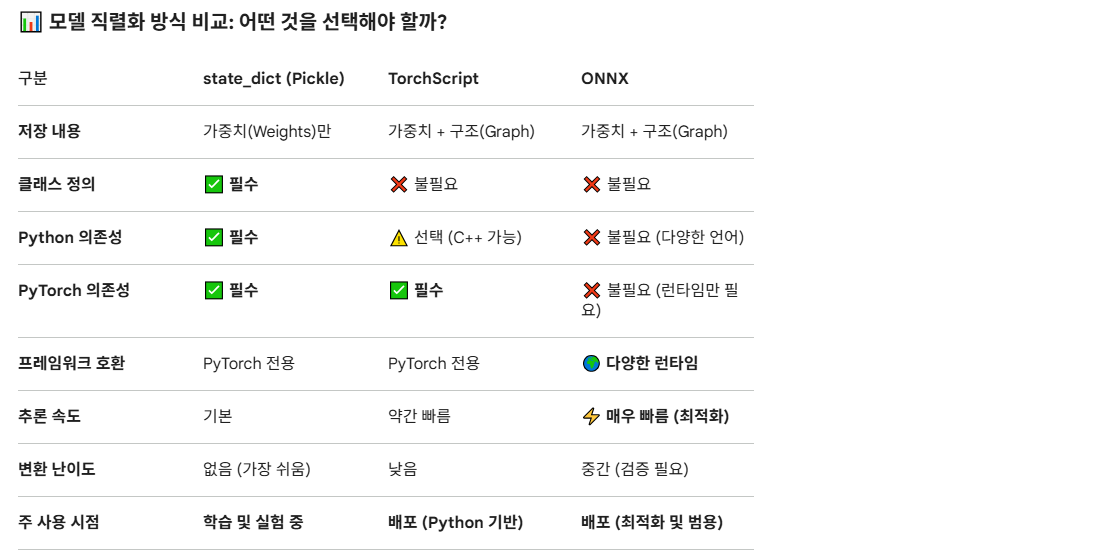


> 💡 **그래서 어떤 것을 써야 합니까?**
>
> 이 과정에서의 권장 기준은 다음과 같습니다:
>
> - **학습 중, 실험 중**: `state_dict` — 가장 간단하고, 학습 재개에 적합합니다.
> - **FastAPI로 서빙 (이 과정의 프로젝트)**: `state_dict` 또는 `TorchScript` — Python 환경이므로 어느 것이든 무방합니다.
> - **성능 최적화가 필요할 때**: `ONNX` + ONNX Runtime — 추론 속도가 중요한 프로덕션 환경에 적합합니다.
>
> 이 과정의 프로젝트에서는 **state_dict 방식**을 기본으로 사용합니다.
> 가장 직관적이고, 디버깅이 쉽기 때문입니다.


> 💡 **그래서 어떤 것을 써야 합니까?**
>
> 이 과정에서의 권장 기준은 다음과 같습니다:
>
> - **학습 중, 실험 중**: `state_dict` — 가장 간단하고, 학습 재개에 적합합니다.
> - **FastAPI로 서빙 (이 과정의 프로젝트)**: `state_dict` 또는 `TorchScript` — Python 환경이므로 어느 것이든 무방합니다.
> - **성능 최적화가 필요할 때**: `ONNX` + ONNX Runtime — 추론 속도가 중요한 프로덕션 환경에 적합합니다.
>
> 이 과정의 프로젝트에서는 **state_dict 방식**을 기본으로 사용합니다.
> 가장 직관적이고, 디버깅이 쉽기 때문입니다.

## 5. 실습: 학습된 모델을 저장하고 다시 불러오기


> **실습 목표**
> - MNIST 데이터셋으로 모델을 실제로 학습합니다.
> - 학습된 모델을 세 가지 방식(state_dict, TorchScript, ONNX)으로 저장합니다.
> - 저장된 모델을 불러와 추론하고, 결과가 동일한지 검증합니다.
> - Day 1 전체 내용을 하나의 워크플로우로 체험합니다.

### 5.1 전체 워크플로우 미리보기

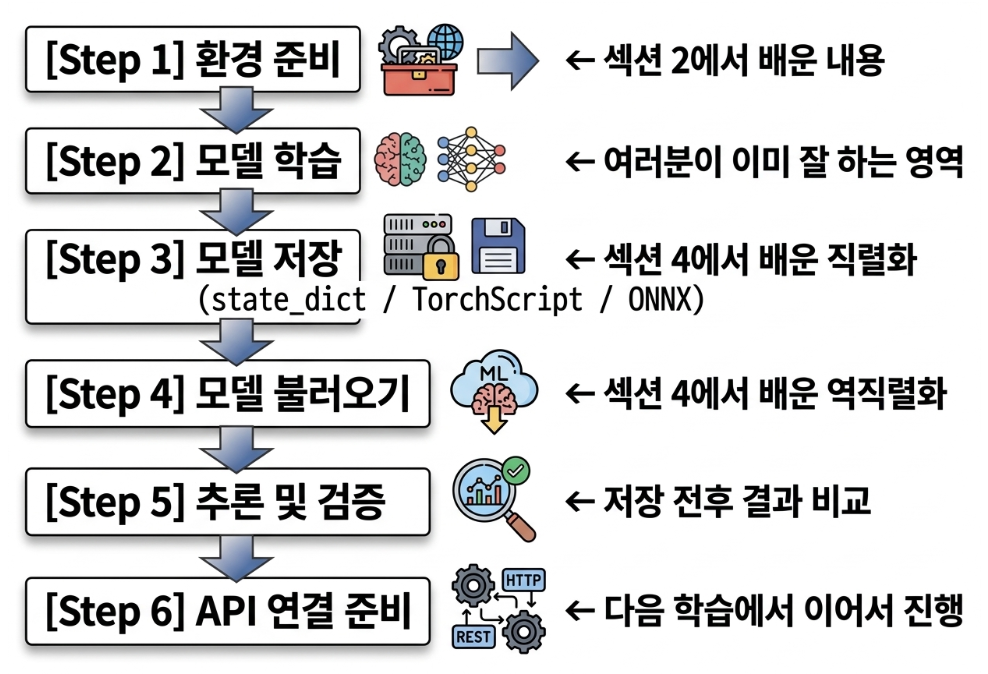

첫 단계는 앞서 완료하였으니, Step2부터 이어 진행하겠습니다.

### 5.2 Step 2 — 모델 학습

MNIST 데이터셋으로 섹션 4에서 정의한 `SimpleClassifier`를 학습합니다.

> 이미 모델 학습에 익숙하시므로, 코드에 대한 상세 설명은 최소화합니다.
> 핵심은 학습이 아니라 **학습 이후의 과정**입니다.

In [102]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [104]:
# ===== 모델 정의 (섹션 4와 동일) =====
class SimpleClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [106]:
# ===== 하이퍼파라미터 =====
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
EPOCHS = 3            # 실습용이므로 3 에포크만 학습합니다

# ===== 디바이스 설정 =====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")

사용 디바이스: cuda


In [108]:
# ===== 데이터 준비 =====
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))   # MNIST 평균/표준편차
])

train_dataset = datasets.MNIST(
    root="data", train=True, download=True, transform=transform
)
test_dataset = datasets.MNIST(
    root="data", train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"학습 데이터: {len(train_dataset):,}장")
print(f"테스트 데이터: {len(test_dataset):,}장")

100%|█████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:02<00:00, 4.27MB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 154kB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:01<00:00, 1.34MB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 4.55MB/s]

학습 데이터: 60,000장
테스트 데이터: 10,000장


In [112]:
model = SimpleClassifier(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [114]:
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # 200 배치마다 진행 상황 출력
        if (batch_idx + 1) % 200 == 0:
            print(f"  Epoch {epoch} [{batch_idx+1}/{len(train_loader)}] "
                  f"Loss: {running_loss/(batch_idx+1):.4f} "
                  f"Acc: {100.*correct/total:.1f}%")

    # 에포크 종료 시 요약
    train_acc = 100. * correct / total
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch}/{EPOCHS} 완료 — Loss: {avg_loss:.4f}, Acc: {train_acc:.1f}%\n")

  Epoch 1 [200/938] Loss: 0.4853 Acc: 84.3%
  Epoch 1 [400/938] Loss: 0.3289 Acc: 89.6%
  Epoch 1 [600/938] Loss: 0.2627 Acc: 91.8%
  Epoch 1 [800/938] Loss: 0.2263 Acc: 93.0%
Epoch 1/3 완료 — Loss: 0.2073, Acc: 93.6%

  Epoch 2 [200/938] Loss: 0.0901 Acc: 97.4%
  Epoch 2 [400/938] Loss: 0.0860 Acc: 97.5%
  Epoch 2 [600/938] Loss: 0.0844 Acc: 97.5%
  Epoch 2 [800/938] Loss: 0.0805 Acc: 97.6%
Epoch 2/3 완료 — Loss: 0.0795, Acc: 97.7%

  Epoch 3 [200/938] Loss: 0.0624 Acc: 98.3%
  Epoch 3 [400/938] Loss: 0.0645 Acc: 98.1%
  Epoch 3 [600/938] Loss: 0.0636 Acc: 98.1%
  Epoch 3 [800/938] Loss: 0.0614 Acc: 98.2%
Epoch 3/3 완료 — Loss: 0.0600, Acc: 98.2%



### 5.3 Step 3 — 세 가지 방식으로 모델 저장

학습이 완료된 모델을 세 가지 방식으로 저장합니다.

> ⚠️ **중요**: 저장 전에 반드시 `model.eval()`을 호출해야 합니다.  
> Dropout, BatchNorm 등은 학습 모드와 추론 모드에서 동작이 다릅니다.
> 추론용으로 저장할 때는 항상 eval 모드에서 진행합니다.

In [116]:
import os
os.makedirs("models", exist_ok=True)

# 모델을 CPU로 이동 (배포 환경에서는 GPU가 없을 수 있으므로)
model_cpu = model.cpu()
model_cpu.eval()

# 추론 비교용 테스트 입력
test_input = test_dataset[0][0].unsqueeze(0)   # 첫 번째 테스트 이미지
test_label = test_dataset[0][1]                 # 정답 레이블

print(f"테스트 입력 크기: {test_input.shape}")
print(f"정답 레이블: {test_label}")

테스트 입력 크기: torch.Size([1, 1, 28, 28])
정답 레이블: 7


In [119]:
# 저장 전 원본 모델의 추론 결과를 기록해 둡니다
with torch.no_grad():
    original_output = model_cpu(test_input)
    original_pred = original_output.argmax(dim=1).item()
    original_conf = torch.softmax(original_output, dim=1).max().item()

print(f"원본 모델 예측: {original_pred} (확신도: {original_conf:.4f})")
print(f"정답:          {test_label}")
print(f"정답 여부:      {'✅ 맞음' if original_pred == test_label else '❌ 틀림'}")


원본 모델 예측: 7 (확신도: 1.0000)
정답:          7
정답 여부:      ✅ 맞음


In [121]:
# 저장 전 원본 모델의 추론 결과를 기록해 둡니다
with torch.no_grad():
    original_output = model_cpu(test_input)
    original_pred = original_output.argmax(dim=1).item()
    original_conf = torch.softmax(original_output, dim=1).max().item()

print(f"원본 모델 예측: {original_pred} (확신도: {original_conf:.4f})")
print(f"정답:          {test_label}")
print(f"정답 여부:      {'✅ 맞음' if original_pred == test_label else '❌ 틀림'}")


원본 모델 예측: 7 (확신도: 1.0000)
정답:          7
정답 여부:      ✅ 맞음


In [123]:
# TorchScript 변환 및 저장
traced_model = torch.jit.trace(model_cpu, test_input)
traced_model.save("models/mnist_traced.pt")
print(f"✅ TorchScript 저장 완료: {os.path.getsize('models/mnist_traced.pt') / 1024:.1f} KB")

✅ TorchScript 저장 완료: 1673.9 KB


In [125]:

import onnxscript

# ONNX 변환 및 저장
torch.onnx.export(
    model_cpu,
    test_input,
    "models/mnist_model.onnx",
    export_params=True,
    opset_version=17,
    input_names=["image"],
    output_names=["prediction"],
    dynamic_axes={
        "image": {0: "batch_size"},
        "prediction": {0: "batch_size"},
    }
)
print(f"✅ ONNX 저장 완료: {os.path.getsize('models/mnist_model.onnx') / 1024:.1f} KB")

✅ ONNX 저장 완료: 1649.1 KB


C:\Users\hugctx\AppData\Local\Temp\ipykernel_16980\589374034.py:4: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


In [127]:
# 저장 결과 요약
print("\n" + "=" * 50)
print("📁 models/ 폴더 내용")
print("=" * 50)
for fname in sorted(os.listdir("models")):
    fpath = os.path.join("models", fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {fname:<30} {size_kb:>8.1f} KB")


📁 models/ 폴더 내용
  mnist_model.onnx                 1649.1 KB
  mnist_traced.pt                  1673.9 KB
  model.onnx                       1649.1 KB
  model_state_dict.pth             1650.9 KB
  model_traced.pt                  1673.2 KB


### 5.4 Step 4 — 불러오기 및 추론 검증

이제 핵심입니다. 저장된 모델을 **각각 독립적으로** 불러와서 추론하고,
원본 결과와 동일한지 검증합니다.

> 이 단계가 중요한 이유:  
> 저장은 성공했는데 불러왔을 때 결과가 다르다면, 배포 후 잘못된 예측을 하게 됩니다.  
> **저장-불러오기-추론 결과의 일관성 검증은 배포 전 필수 절차입니다.**

### 검증 1: state_dict

In [131]:
# 클래스 정의가 반드시 있어야 합니다
loaded_sd = SimpleClassifier(num_classes=10)
loaded_sd.load_state_dict(
    torch.load("models/mnist_state_dict.pth", weights_only=True)
)
loaded_sd.eval()

with torch.no_grad():
    sd_output = loaded_sd(test_input)
    sd_pred = sd_output.argmax(dim=1).item()

print(f"[state_dict] 예측: {sd_pred}, 원본과 일치: {torch.allclose(original_output, sd_output)}")

FileNotFoundError: [Errno 2] No such file or directory: 'models/mnist_state_dict.pth'